# 시각화

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
mpg = pd.read_csv("./Data/mpg.csv")
mpg.shape

(234, 11)

In [5]:
mpg.head(2)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact


<Axes: xlabel='displ', ylabel='hwy'>

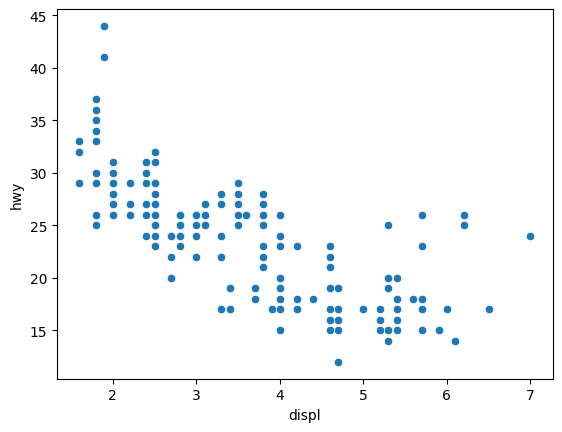

In [7]:
sns.scatterplot(data=mpg, x="displ", y="hwy")


[(3.0, 6.0), (20.0, 25.0)]

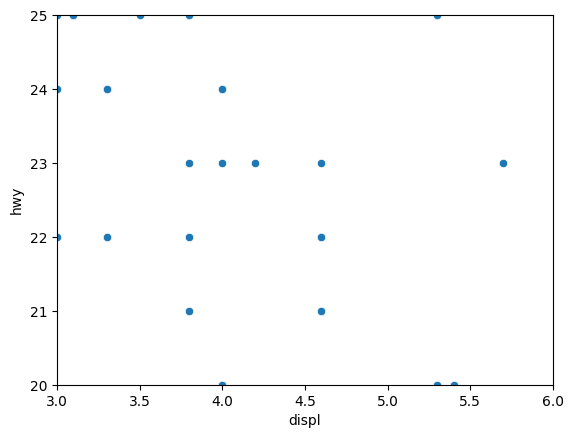

In [10]:
sns.scatterplot(data=mpg, x="displ", y="hwy").set(xlim = [3, 6], ylim = [20, 25])

<Axes: xlabel='displ', ylabel='hwy'>

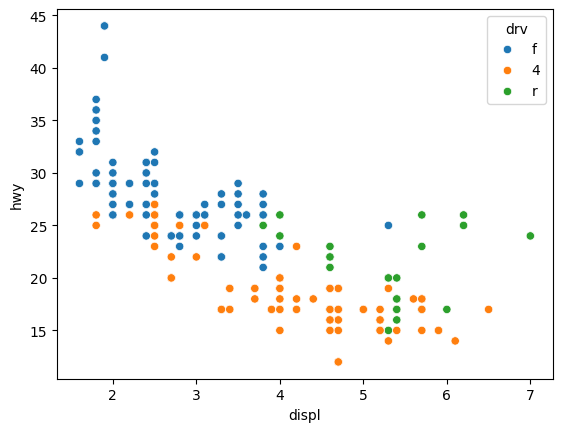

In [11]:
sns.scatterplot(data= mpg, x = "displ", y = "hwy", hue = "drv")

# 그래프 설정 

In [ ]:
import matplotlib.pyplot as plt

In [55]:
plt.rcParams.update({"figure.dpi": "150"}) # 기본값 72
plt.rcParams.update({"figure.figsize": [8, 6]}) # 기본값 [6, 4]
plt.rcParams.update({"font.size": "15"})
plt.rcParams.update({"font.family": "Consolas"})

<Axes: xlabel='displ', ylabel='hwy'>

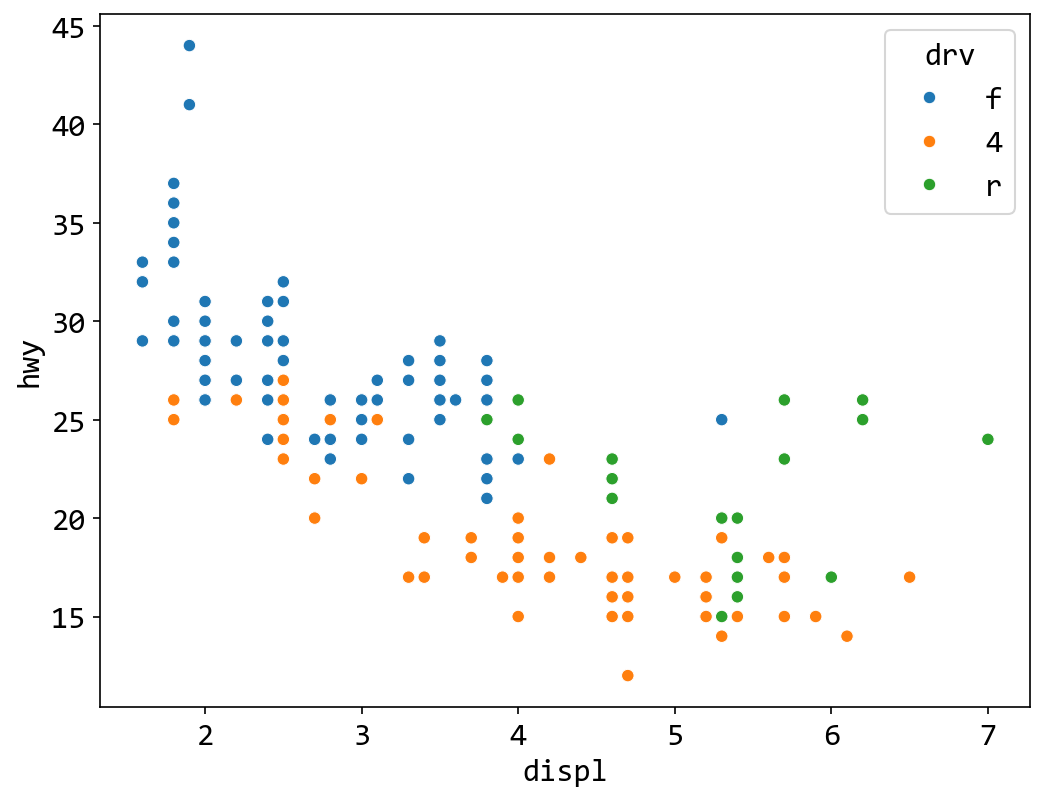

In [56]:
sns.scatterplot(data = mpg, x = "displ", y = "hwy", hue = "drv")

In [58]:
df_mpg = mpg.groupby("drv", as_index=False).agg(mean_hwy = ("hwy", "mean"))
df_mpg

,drv,mean_hwy
0,4,19.174757
1,f,28.160377
2,r,21.000000


# 그룹간 값의 크기 비교의 대표적인 차트 = 막대그래프

<Axes: xlabel='drv', ylabel='mean_hwy'>

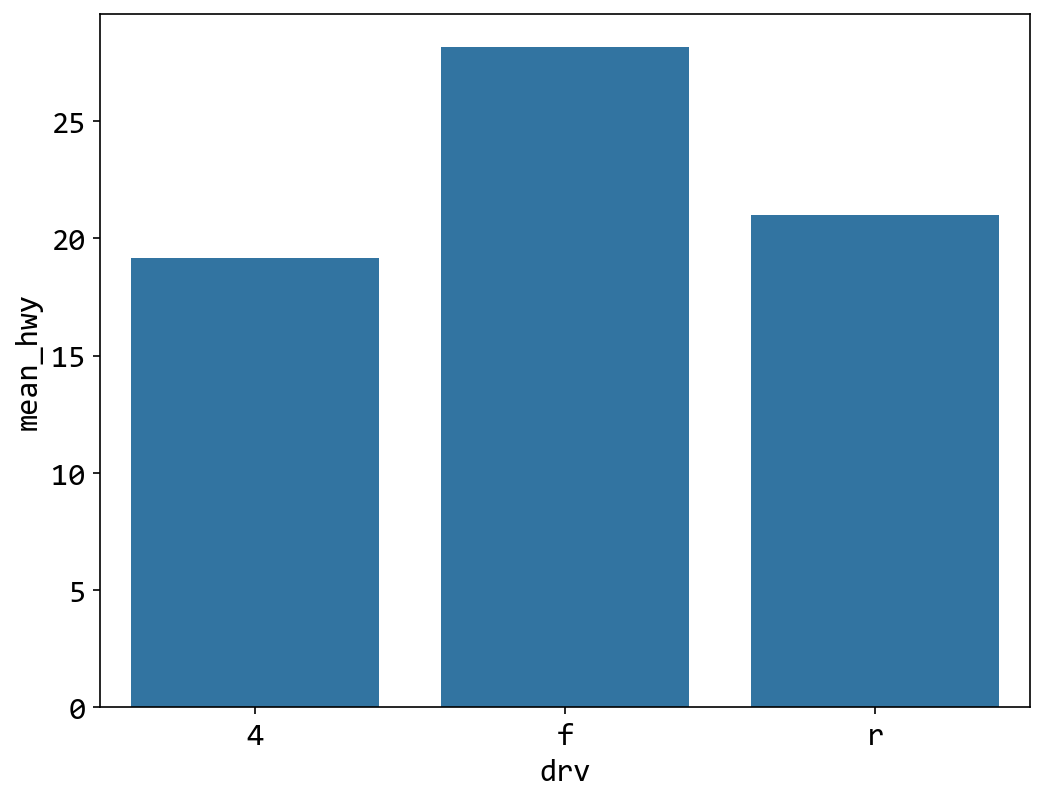

In [59]:
sns.barplot(data = df_mpg, x = "drv", y = "mean_hwy")
# plt.savefig("abc.png")

In [60]:
df_mpg = df_mpg.sort_values("mean_hwy", ascending=False)

In [61]:
df_mpg = mpg.groupby("drv", as_index=False).agg(n = ("drv", "count"))
df_mpg

,drv,n
0,4,103
1,f,106
2,r,25


<Axes: xlabel='drv', ylabel='Count'>

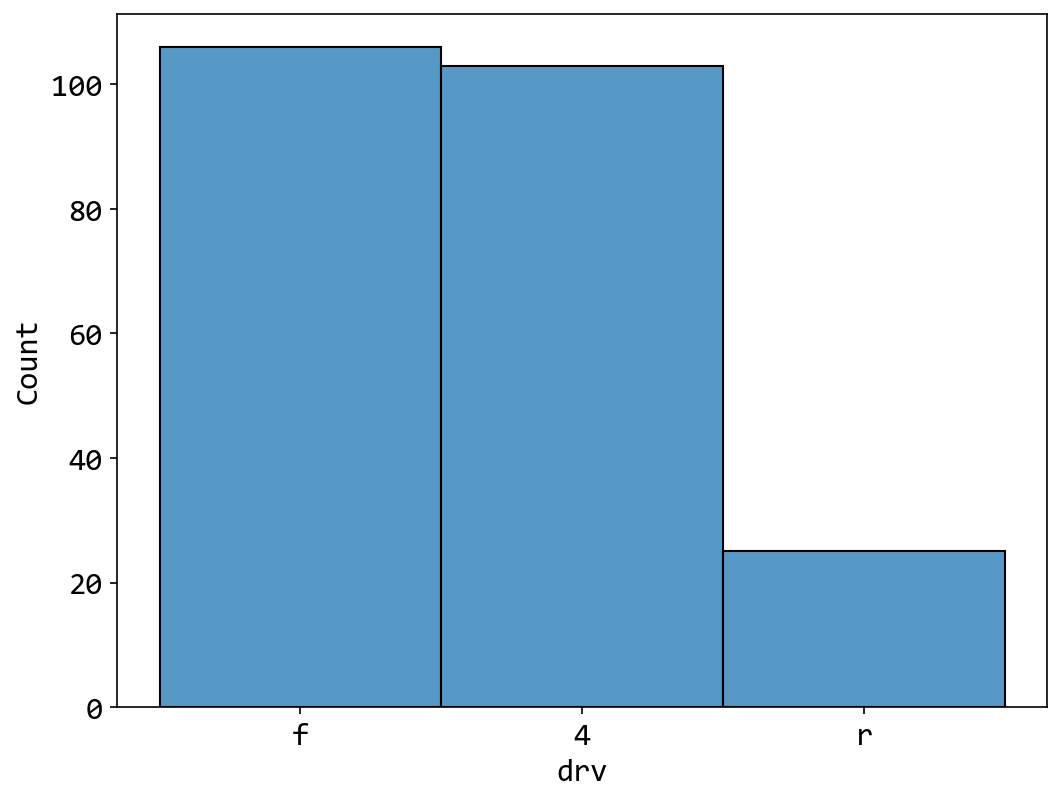

In [62]:
sns.histplot(data=mpg, x="drv")

In [63]:
mpg["drv"].unique()

<StringArray>
['f', '4', 'r']
Length: 3, dtype: str

In [64]:
mpg["manufacturer"].unique()

<StringArray>
[      'audi',  'chevrolet',      'dodge',       'ford',      'honda',
    'hyundai',       'jeep', 'land rover',    'lincoln',    'mercury',
     'nissan',    'pontiac',     'subaru',     'toyota', 'volkswagen']
Length: 15, dtype: str

In [65]:
mpg["drv"].nunique()

3

In [66]:
mpg["manufacturer"].nunique()

15

<Axes: xlabel='drv', ylabel='count'>

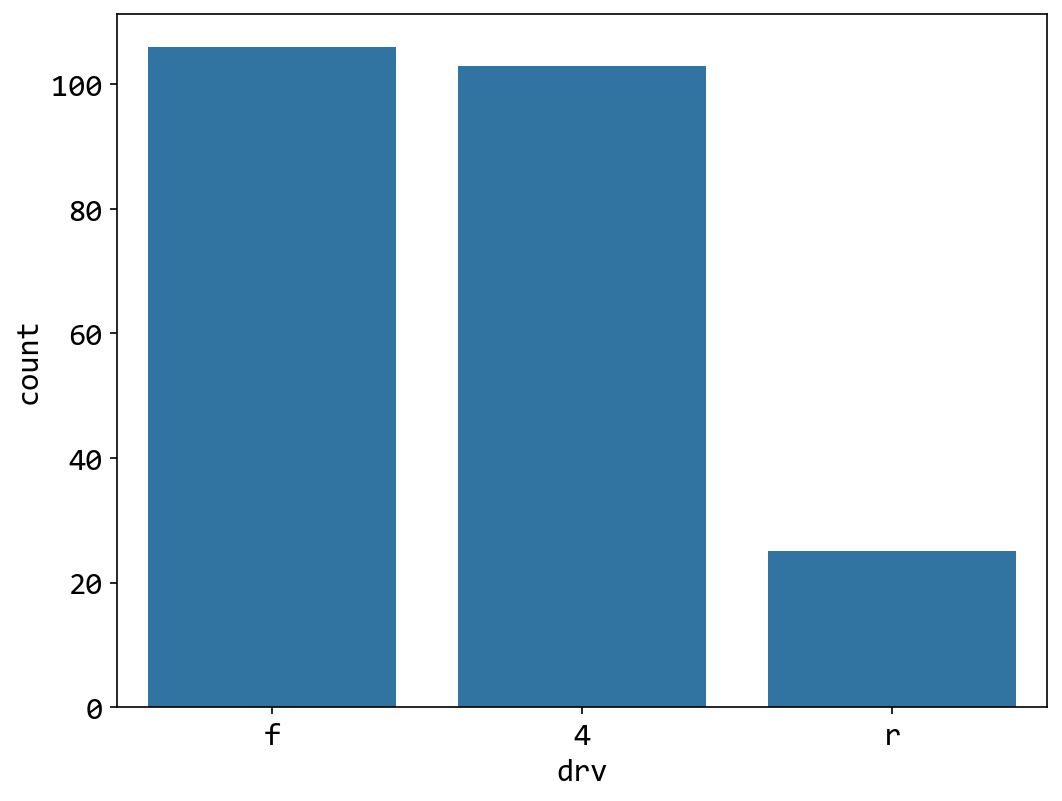

In [67]:
sns.countplot(data=mpg, x = "drv", order=["f", "4", "r"])

In [70]:
mpg["drv"].value_counts().index

Index(['f', '4', 'r'], dtype='str', name='drv')

<Axes: xlabel='drv', ylabel='count'>

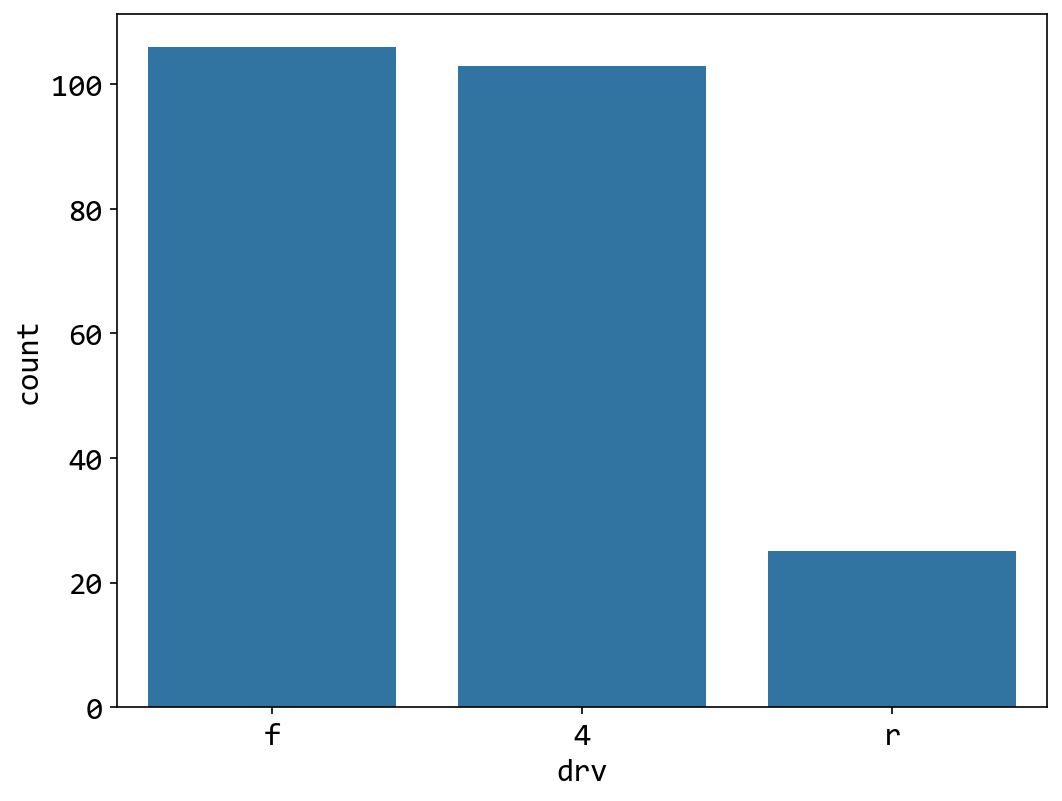

In [71]:
sns.countplot(data=mpg, x = "drv", order=mpg["drv"].value_counts().index)

# 연속형 데이터, 시간에 따라 값이 달라지는 데이터(시계열) - 선그래프

In [84]:
economics = pd.read_csv("./Data/economics.csv")
economics.shape

(574, 6)

In [85]:
economics.head(2)

,date,pce,pop,psavert,uempmed,unemploy
0,1967-07-01,506.7,198712.0,12.6,4.5,2944
1,1967-08-01,509.8,198911.0,12.6,4.7,2945


<Axes: xlabel='date', ylabel='unemploy'>

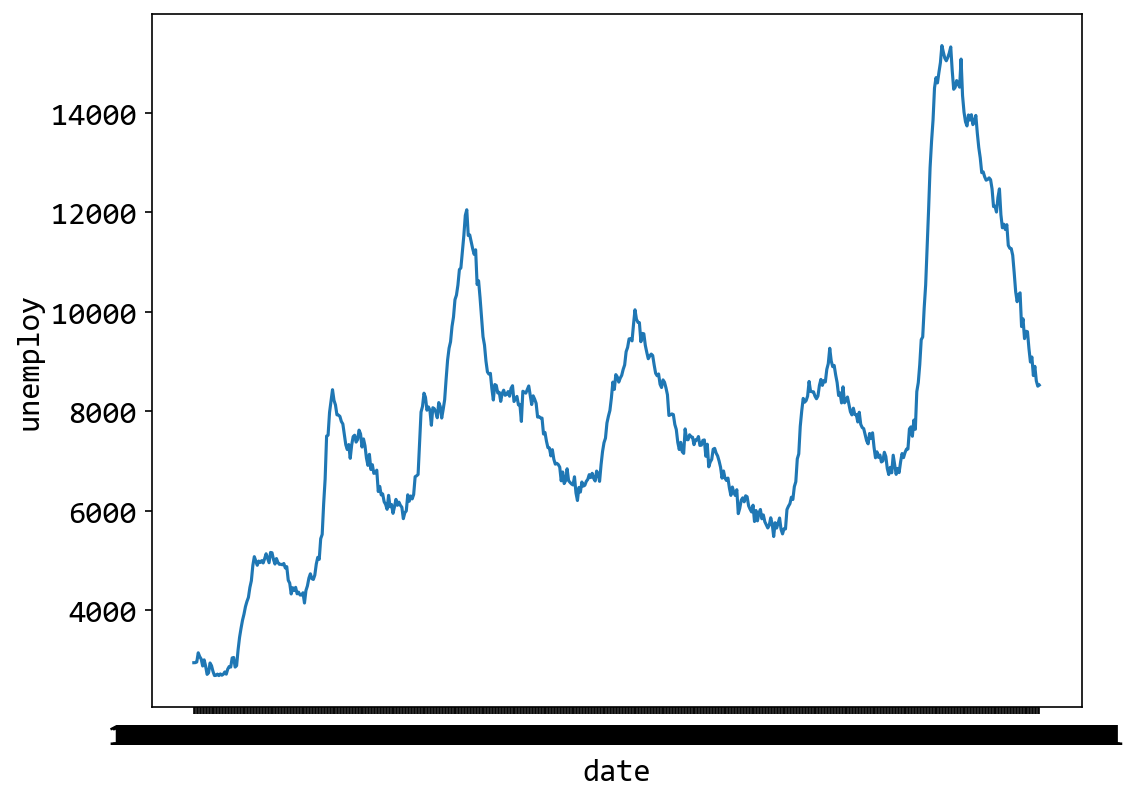

In [86]:
sns.lineplot(data=economics, x = "date", y ="unemploy")

In [87]:
economics.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      574 non-null    str    
 1   pce       574 non-null    float64
 2   pop       574 non-null    float64
 3   psavert   574 non-null    float64
 4   uempmed   574 non-null    float64
 5   unemploy  574 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 27.0 KB


In [91]:
economics["date2"] = pd.to_datetime(economics["date"])
economics.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      574 non-null    str           
 1   pce       574 non-null    float64       
 2   pop       574 non-null    float64       
 3   psavert   574 non-null    float64       
 4   uempmed   574 non-null    float64       
 5   unemploy  574 non-null    int64         
 6   date2     574 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 31.5 KB


In [92]:
economics[["date", "date2"]]

,date,date2
0,1967-07-01,1967-07-01
1,1967-08-01,1967-08-01
2,1967-09-01,1967-09-01
3,1967-10-01,1967-10-01
4,1967-11-01,1967-11-01
...,...,...
569,2014-12-01,2014-12-01
570,2015-01-01,2015-01-01
571,2015-02-01,2015-02-01
572,2015-03-01,2015-03-01


In [93]:
economics["date"].str.split("-")

0      [1967, 07, 01]
1      [1967, 08, 01]
2      [1967, 09, 01]
3      [1967, 10, 01]
4      [1967, 11, 01]
            ...      
569    [2014, 12, 01]
570    [2015, 01, 01]
571    [2015, 02, 01]
572    [2015, 03, 01]
573    [2015, 04, 01]
Name: date, Length: 574, dtype: object

In [94]:
economics["date2"].dt.month_name()

0           July
1         August
2      September
3        October
4       November
         ...    
569     December
570      January
571     February
572        March
573        April
Name: date2, Length: 574, dtype: str

In [102]:
economics["year"] = economics["date2"].dt.year
economics.head(2)

,date,pce,pop,psavert,uempmed,unemploy,date2,year
0,1967-07-01,506.7,198712.0,12.6,4.5,2944,1967-07-01,1967
1,1967-08-01,509.8,198911.0,12.6,4.7,2945,1967-08-01,1967


<Axes: xlabel='year', ylabel='unemploy'>

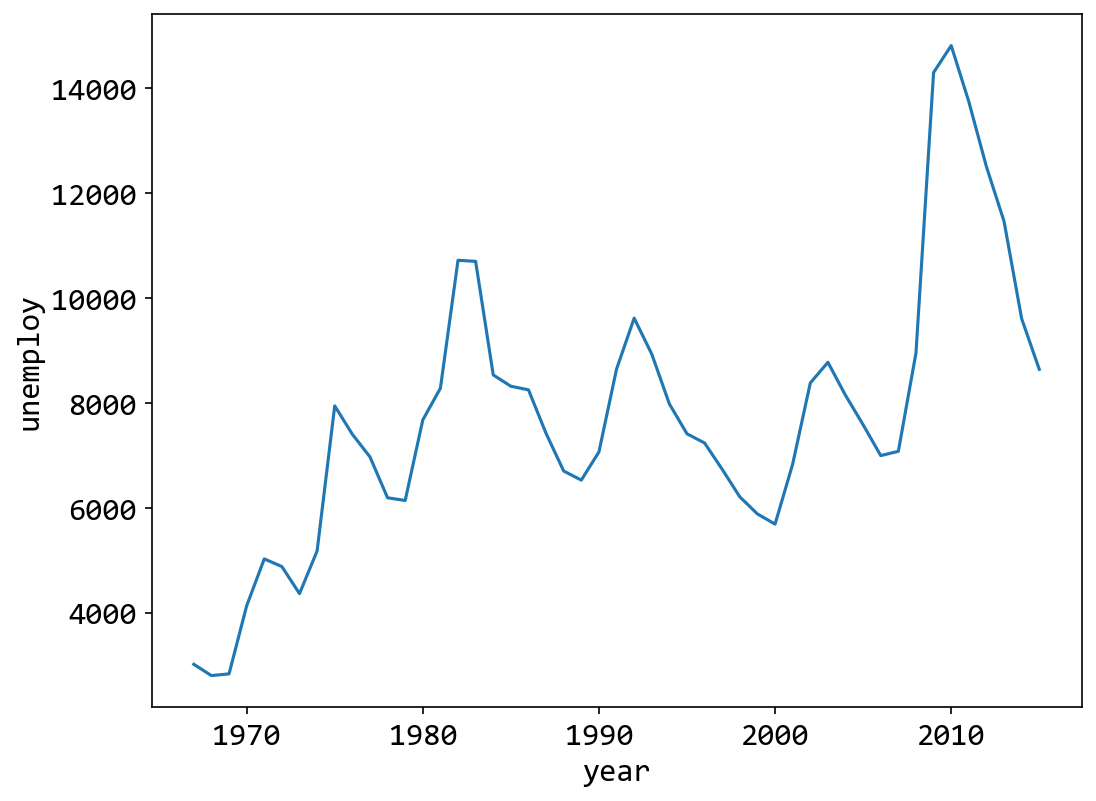

In [104]:
sns.lineplot(data=economics, x = "year", y = "unemploy", errorbar  = None) #신뢰구간 제거

# 상장 그림 - 박스플롯

<Axes: xlabel='drv', ylabel='hwy'>

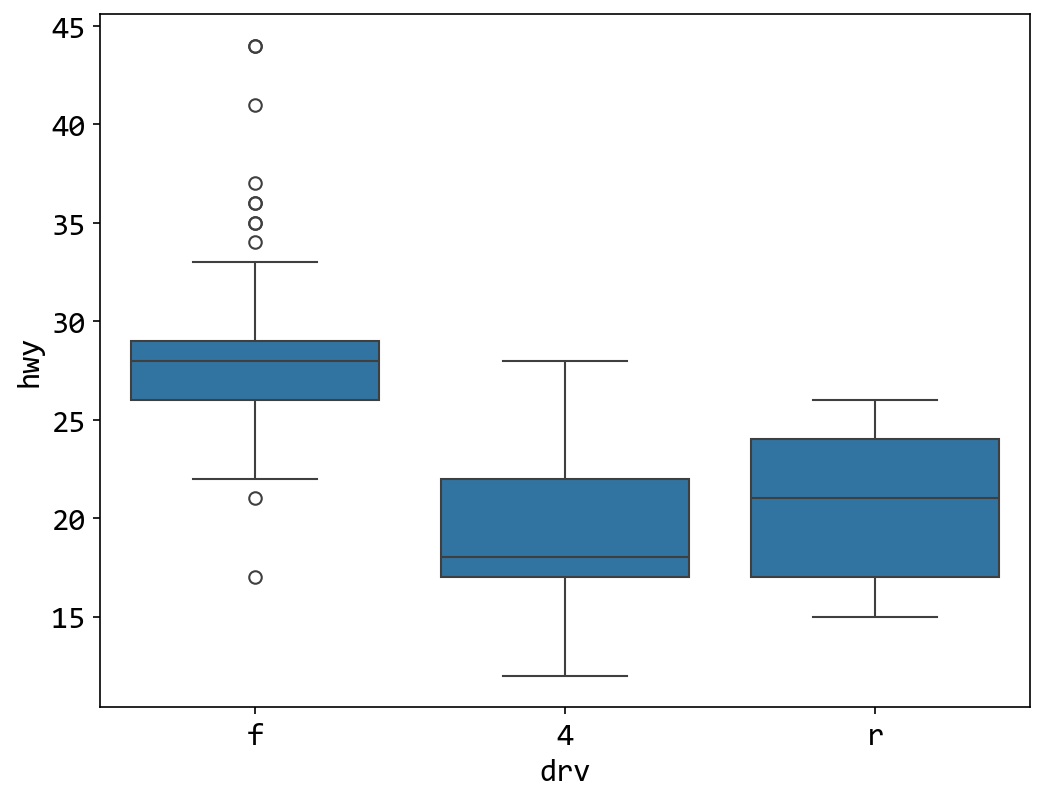

In [105]:
sns.boxplot(data = mpg, x = "drv", y = "hwy")